Yuva Interns – Logistics Data Analysis Internship
Week 2 Task: Data Collection, Cleaning, and Preprocessing
Dataset: DataCo SMART Supply Chain Dataset
Tools: Python, Pandas, NumPy, Matplotlib & Scikit-learn


In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [2]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Extracted files:")

for root, dirs, files_list in os.walk('/content/dataset'):
    for file in files_list:
        print(os.path.join(root, file))

Extracted files:
/content/dataset/tokenized_access_logs.csv
/content/dataset/DataCoSupplyChainDataset.csv
/content/dataset/DescriptionDataCoSupplyChain.csv


In [3]:
import glob

csv_files = glob.glob('/content/dataset/**/*.csv', recursive=True)

print("CSV files found:")

for file in csv_files:
    print(file)

CSV files found:
/content/dataset/tokenized_access_logs.csv
/content/dataset/DataCoSupplyChainDataset.csv
/content/dataset/DescriptionDataCoSupplyChain.csv


In [4]:
import pandas as pd
import numpy as np

# Load the main logistics dataset
file_path = '/content/dataset/DataCoSupplyChainDataset.csv'

df = pd.read_csv(file_path, encoding='latin1')

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 180519
Number of columns: 53


In [5]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
Product Description,180519
Order Zipcode,155679
Customer Lname,8
Customer Zipcode,3
Days for shipment (scheduled),0
Sales per customer,0
Benefit per order,0
Delivery Status,0
Late_delivery_risk,0
Customer City,0


In [8]:
description_df = pd.read_csv(
    '/content/dataset/DescriptionDataCoSupplyChain.csv',
    encoding='latin1'
)

description_df.head(20)

,FIELDS,DESCRIPTION
0,Type,: Type of transaction made
1,Days for shipping (real),: Actual shipping days of the purchased product
2,Days for shipment (scheduled),: Days of scheduled delivery of the purchased...
3,Benefit per order,: Earnings per order placed
4,Sales per customer,: Total sales per customer made per customer
5,Delivery Status,: Delivery status of orders: Advance shipping...
6,Late_delivery_risk,: Categorical variable that indicates if send...
7,Category Id,: Product category code
8,Category Name,: Description of the product category
9,Customer City,: City where the customer made the purchase


In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 180519
Columns: 53


In [10]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [11]:
print("Column Names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column Names:
1. Type
2. Days for shipping (real)
3. Days for shipment (scheduled)
4. Benefit per order
5. Sales per customer
6. Delivery Status
7. Late_delivery_risk
8. Category Id
9. Category Name
10. Customer City
11. Customer Country
12. Customer Email
13. Customer Fname
14. Customer Id
15. Customer Lname
16. Customer Password
17. Customer Segment
18. Customer State
19. Customer Street
20. Customer Zipcode
21. Department Id
22. Department Name
23. Latitude
24. Longitude
25. Market
26. Order City
27. Order Country
28. Order Customer Id
29. order date (DateOrders)
30. Order Id
31. Order Item Cardprod Id
32. Order Item Discount
33. Order Item Discount Rate
34. Order Item Id
35. Order Item Product Price
36. Order Item Profit Ratio
37. Order Item Quantity
38. Sales
39. Order Item Total
40. Order Profit Per Order
41. Order Region
42. Order State
43. Order Status
44. Order Zipcode
45. Product Card Id
46. Product Category Id
47. Product Description
48. Product Image
49. Product Name
50. Pr

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [13]:
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64


In [14]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [15]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,180519,4,DEBIT,69295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days for shipping (real),180519.0,NaN,NaN,NaN,3.497654,1.623722,0.0,2.0,3.0,5.0,6.0
Days for shipment (scheduled),180519.0,NaN,NaN,NaN,2.931847,1.374449,0.0,2.0,4.0,4.0,4.0
Benefit per order,180519.0,NaN,NaN,NaN,21.974989,104.433526,-4274.97998,7.0,31.52,64.800003,911.799988
Sales per customer,180519.0,NaN,NaN,NaN,183.107609,120.04367,7.49,104.379997,163.990005,247.399994,1939.98999
Delivery Status,180519,4,Late delivery,98977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Late_delivery_risk,180519.0,NaN,NaN,NaN,0.548291,0.497664,0.0,0.0,1.0,1.0,1.0
Category Id,180519.0,NaN,NaN,NaN,31.851451,15.640064,2.0,18.0,29.0,45.0,76.0
Category Name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer City,180519,563,Caguas,66770,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Missing value analysis

missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary['Missing Count'] > 0
].sort_values('Missing Percentage', ascending=False)

missing_summary

,Missing Count,Missing Percentage
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Zipcode,3,0.00
Customer Lname,8,0.00


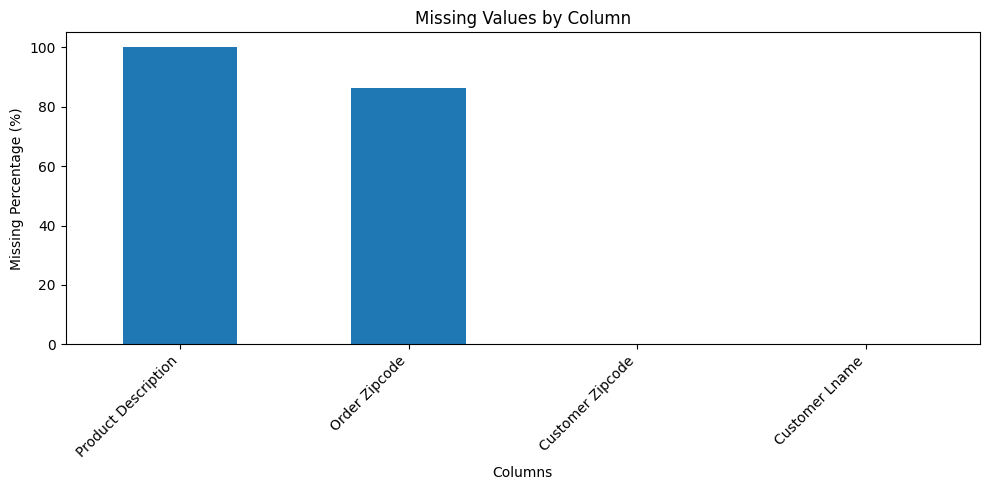

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

missing_summary['Missing Percentage'].plot(kind='bar')

plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Inspect records with missing Customer Lname or Customer Zipcode

df[df['Customer Lname'].isnull() | df['Customer Zipcode'].isnull()][
    ['Customer Fname', 'Customer Lname', 'Customer City',
     'Customer State', 'Customer Zipcode']
]

,Customer Fname,Customer Lname,Customer City,Customer State,Customer Zipcode
35704,Sara,Foreman,CA,95758,NaN
41422,May,NaN,Caguas,PR,725.0
46440,Eugenia,Slater,CA,95758,NaN
50447,Contreras,NaN,Palatine,IL,60067.0
82511,Zena,Elliott,CA,91732,NaN
86260,Ray,NaN,Los Angeles,CA,90027.0
92621,BlueOneal,NaN,Caguas,PR,725.0
97530,York,NaN,San Antonio,TX,78240.0
120404,Farley,NaN,Fayetteville,NC,28314.0
166129,Le,NaN,Honolulu,HI,96822.0


In [19]:
# Create a copy of the original dataset
df_clean = df.copy()

print("Original shape:", df_clean.shape)

Original shape: (180519, 53)


In [20]:
# Remove columns with excessive missing data

df_clean = df_clean.drop(columns=[
    'Product Description',
    'Order Zipcode'
])

print("Shape after dropping high-missing columns:", df_clean.shape)

Shape after dropping high-missing columns: (180519, 51)


In [21]:
# Fill missing customer last names
df_clean['Customer Lname'] = df_clean['Customer Lname'].fillna('Unknown')

# Fill missing customer zipcodes using the median
df_clean['Customer Zipcode'] = df_clean['Customer Zipcode'].fillna(
    df_clean['Customer Zipcode'].median()
)

print("Missing values after treatment:",
      df_clean.isnull().sum().sum())

Missing values after treatment: 0


In [22]:
# Verify that no missing values remain

remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining columns with missing values:")
print(remaining_missing)

Remaining columns with missing values:
Series([], dtype: int64)


In [23]:
# Check current data types

print("Data types before preprocessing:")
print(df_clean.dtypes)

Data types before preprocessing:
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude               

In [24]:
# Check date columns

print("Order date sample:")
print(df_clean['order date (DateOrders)'].head())

print("\nShipping date sample:")
print(df_clean['shipping date (DateOrders)'].head())

Order date sample:
0    1/31/2018 22:56
1    1/13/2018 12:27
2    1/13/2018 12:06
3    1/13/2018 11:45
4    1/13/2018 11:24
Name: order date (DateOrders), dtype: object

Shipping date sample:
0     2/3/2018 22:56
1    1/18/2018 12:27
2    1/17/2018 12:06
3    1/16/2018 11:45
4    1/15/2018 11:24
Name: shipping date (DateOrders), dtype: object


In [25]:
# Convert date columns to datetime

df_clean['order date (DateOrders)'] = pd.to_datetime(
    df_clean['order date (DateOrders)'],
    errors='coerce'
)

df_clean['shipping date (DateOrders)'] = pd.to_datetime(
    df_clean['shipping date (DateOrders)'],
    errors='coerce'
)

print("Date conversion completed.")

Date conversion completed.


In [26]:
print(df_clean[['order date (DateOrders)',
                'shipping date (DateOrders)']].dtypes)

order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object


In [27]:
# Check for invalid/unconvertible dates

print("Invalid order dates:",
      df_clean['order date (DateOrders)'].isna().sum())

print("Invalid shipping dates:",
      df_clean['shipping date (DateOrders)'].isna().sum())

Invalid order dates: 0
Invalid shipping dates: 0


In [28]:
date_issue = df_clean[
    df_clean['shipping date (DateOrders)'] <
    df_clean['order date (DateOrders)']
]

print("Records where shipping date is before order date:",
      len(date_issue))

Records where shipping date is before order date: 0


In [29]:
print("Date consistency check completed.")

Date consistency check completed.


In [30]:
date_issue = df_clean[
    df_clean['shipping date (DateOrders)'] <
    df_clean['order date (DateOrders)']
]

print("Records where shipping date is before order date:", len(date_issue))

Records where shipping date is before order date: 0


In [31]:
numeric_columns = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Sales',
    'Order Item Discount',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Profit Per Order'
]

print("Outlier analysis columns:")
print(numeric_columns)

Outlier analysis columns:
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Sales', 'Order Item Discount', 'Order Item Product Price', 'Order Item Quantity', 'Order Profit Per Order']


In [32]:
Q1 = df_clean[numeric_columns].quantile(0.25)
Q3 = df_clean[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    ((df_clean[numeric_columns] < lower_bound) |
     (df_clean[numeric_columns] > upper_bound))
    .sum()
)

print("Outlier counts:")
print(outlier_counts)

Outlier counts:
Days for shipping (real)             0
Days for shipment (scheduled)        0
Sales                              488
Order Item Discount               7537
Order Item Product Price          2048
Order Item Quantity                  0
Order Profit Per Order           18942
dtype: int64


In [33]:
print("Outlier variable statistics:")
print(df_clean[numeric_columns].describe().T[
    ['min', '25%', '50%', '75%', 'max']
])

Outlier variable statistics:
                                      min         25%         50%         75%  \
Days for shipping (real)          0.00000    2.000000    3.000000    5.000000   
Days for shipment (scheduled)     0.00000    2.000000    4.000000    4.000000   
Sales                             9.99000  119.980003  199.919998  299.950012   
Order Item Discount               0.00000    5.400000   14.000000   29.990000   
Order Item Product Price          9.99000   50.000000   59.990002  199.990005   
Order Item Quantity               1.00000    1.000000    1.000000    3.000000   
Order Profit Per Order        -4274.97998    7.000000   31.520000   64.800003   

                                       max  
Days for shipping (real)          6.000000  
Days for shipment (scheduled)     4.000000  
Sales                          1999.989990  
Order Item Discount             500.000000  
Order Item Product Price       1999.989990  
Order Item Quantity               5.000000  
Order P

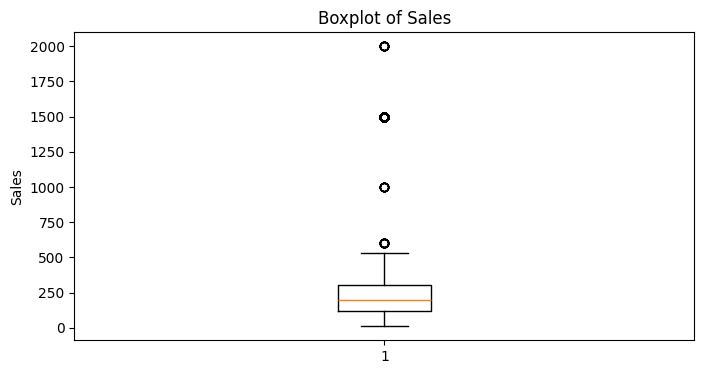

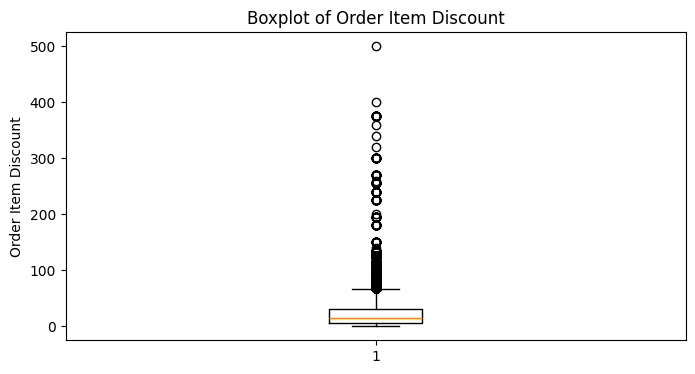

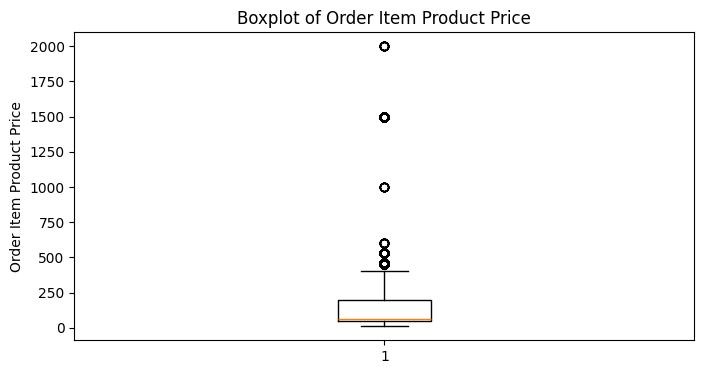

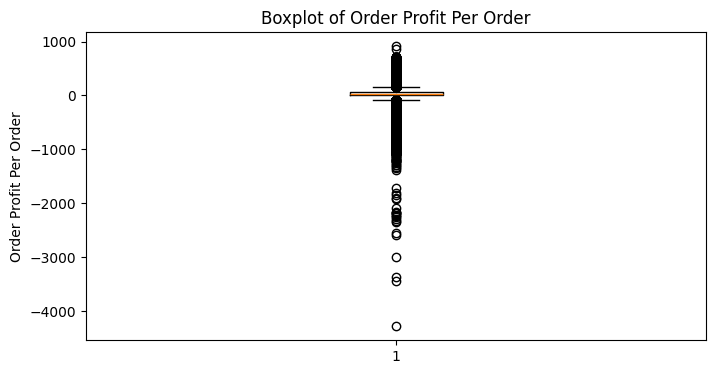

In [34]:
import matplotlib.pyplot as plt

outlier_columns = [
    'Sales',
    'Order Item Discount',
    'Order Item Product Price',
    'Order Profit Per Order'
]

for column in outlier_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_clean[column].dropna())
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.show()

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaling_columns = [
    'Sales',
    'Order Item Discount',
    'Order Item Product Price',
    'Order Profit Per Order'
]

scaler = MinMaxScaler()

df_clean_scaled = df_clean.copy()

df_clean_scaled[scaling_columns] = scaler.fit_transform(
    df_clean[scaling_columns]
)

print("Normalization completed successfully.")

Normalization completed successfully.


In [36]:
print("Before normalization:")
print(df_clean[scaling_columns].describe().loc[['min', 'max']])

print("\nAfter normalization:")
print(df_clean_scaled[scaling_columns].describe().loc[['min', 'max']])

Before normalization:
          Sales  Order Item Discount  Order Item Product Price  \
min     9.99000                  0.0                   9.99000   
max  1999.98999                500.0                1999.98999   

     Order Profit Per Order  
min            -4274.979980  
max              911.799988  

After normalization:
     Sales  Order Item Discount  Order Item Product Price  \
min    0.0                  0.0                       0.0   
max    1.0                  1.0                       1.0   

     Order Profit Per Order  
min                     0.0  
max                     1.0  


In [37]:
print("Total missing values:", df_clean_scaled.isnull().sum().sum())

Total missing values: 0


In [38]:
print("Total duplicate rows:", df_clean_scaled.duplicated().sum())

Total duplicate rows: 0


In [39]:
print("Final dataset shape:", df_clean_scaled.shape)

Final dataset shape: (180519, 51)


In [40]:
print("Final data types:")
print(df_clean_scaled.dtypes)

Final data types:
Type                                     object
Days for shipping (real)                  int64
Days for shipment (scheduled)             int64
Benefit per order                       float64
Sales per customer                      float64
Delivery Status                          object
Late_delivery_risk                        int64
Category Id                               int64
Category Name                            object
Customer City                            object
Customer Country                         object
Customer Email                           object
Customer Fname                           object
Customer Id                               int64
Customer Lname                           object
Customer Password                        object
Customer Segment                         object
Customer State                           object
Customer Street                          object
Customer Zipcode                        float64
Department Id         

In [41]:
print("Total missing values:", df_clean_scaled.isnull().sum().sum())

Total missing values: 0


In [42]:
print("Total duplicate rows:", df_clean_scaled.duplicated().sum())

Total duplicate rows: 0


In [43]:
print("Final dataset shape:", df_clean_scaled.shape)

Final dataset shape: (180519, 51)


In [44]:
print("Total missing values:", df_clean_scaled.isnull().sum().sum())

Total missing values: 0


In [45]:
print("Total duplicate rows:", df_clean_scaled.duplicated().sum())

Total duplicate rows: 0


In [46]:
print("Total missing values:", df_clean_scaled.isnull().sum().sum())

Total missing values: 0


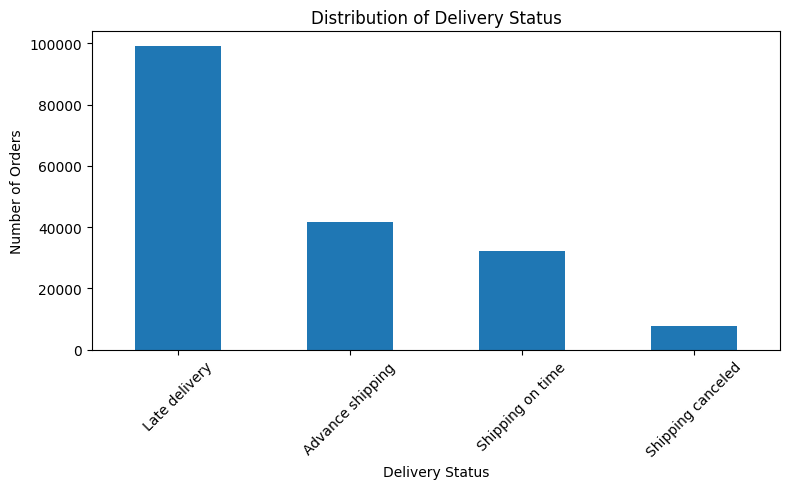

In [47]:
import matplotlib.pyplot as plt

delivery_counts = df_clean['Delivery Status'].value_counts()

plt.figure(figsize=(8, 5))
delivery_counts.plot(kind='bar')

plt.title('Distribution of Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
print("Delivery Status counts:")
print(delivery_counts)

Delivery Status counts:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


In [49]:
shipping_mode_counts = df_clean['Shipping Mode'].value_counts()

print("Shipping Mode counts:")
print(shipping_mode_counts)

Shipping Mode counts:
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


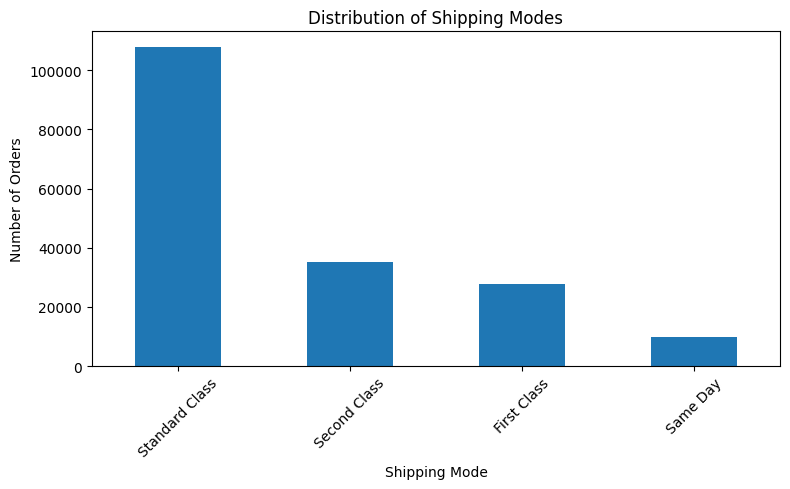

In [50]:
plt.figure(figsize=(8, 5))
shipping_mode_counts.plot(kind='bar')

plt.title('Distribution of Shipping Modes')
plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
print("Shipping Mode counts:")
print(shipping_mode_counts)

Shipping Mode counts:
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


In [52]:
shipping_comparison = df_clean[
    ['Days for shipping (real)', 'Days for shipment (scheduled)']
].mean()

print("Average shipping days:")
print(shipping_comparison)

Average shipping days:
Days for shipping (real)         3.497654
Days for shipment (scheduled)    2.931847
dtype: float64


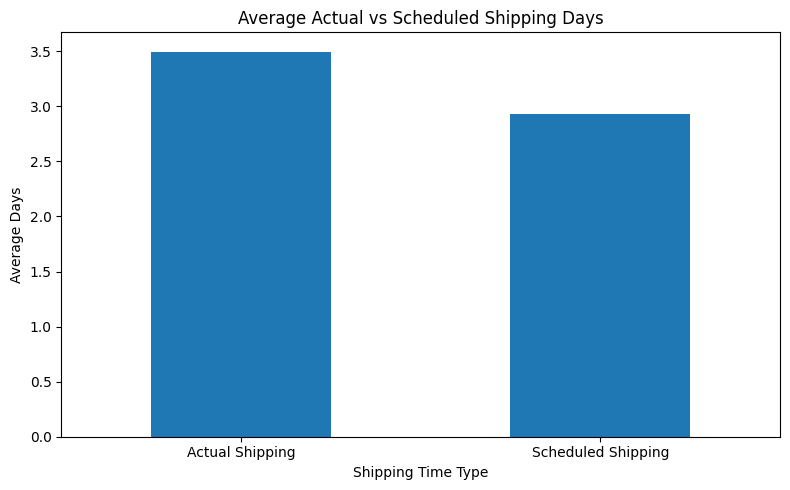

In [53]:
plt.figure(figsize=(8, 5))

shipping_comparison.plot(kind='bar')

plt.title('Average Actual vs Scheduled Shipping Days')
plt.xlabel('Shipping Time Type')
plt.ylabel('Average Days')
plt.xticks(
    [0, 1],
    ['Actual Shipping', 'Scheduled Shipping'],
    rotation=0
)

plt.tight_layout()
plt.show()

In [54]:
print(shipping_comparison)

Days for shipping (real)         3.497654
Days for shipment (scheduled)    2.931847
dtype: float64


In [55]:
delivery_by_mode = pd.crosstab(
    df_clean['Shipping Mode'],
    df_clean['Delivery Status']
)

print("Delivery status by shipping mode:")
print(delivery_by_mode)

Delivery status by shipping mode:
Delivery Status  Advance shipping  Late delivery  Shipping canceled  \
Shipping Mode                                                         
First Class                     0          26513               1301   
Same Day                        0           4454                444   
Second Class                    0          26987               1410   
Standard Class              41592          41023               4599   

Delivery Status  Shipping on time  
Shipping Mode                      
First Class                     0  
Same Day                     4839  
Second Class                 6819  
Standard Class              20538  


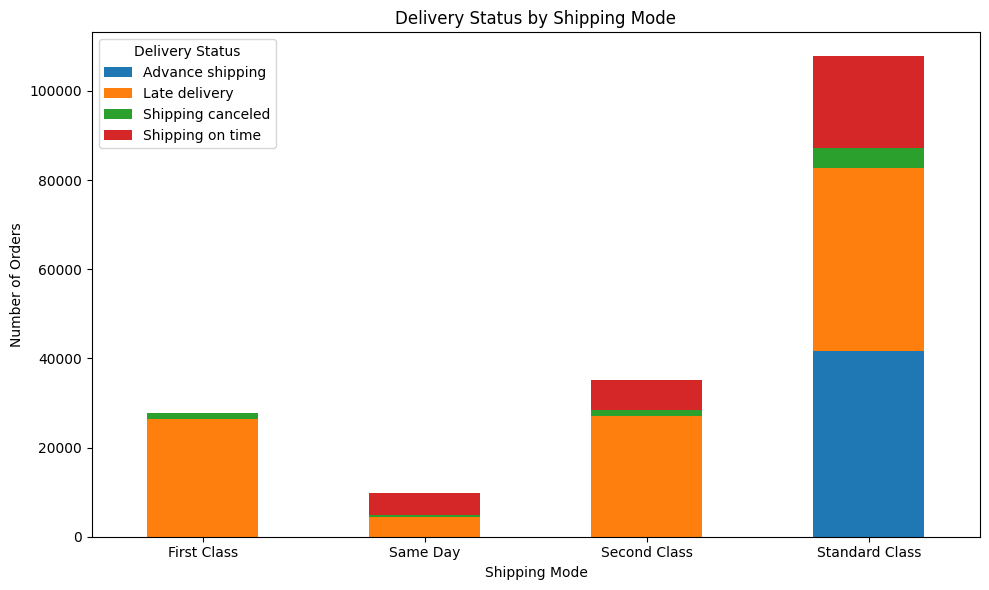

In [56]:
delivery_by_mode.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Delivery Status by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.legend(title='Delivery Status')
plt.tight_layout()
plt.show()

In [57]:
print(delivery_by_mode)

Delivery Status  Advance shipping  Late delivery  Shipping canceled  \
Shipping Mode                                                         
First Class                     0          26513               1301   
Same Day                        0           4454                444   
Second Class                    0          26987               1410   
Standard Class              41592          41023               4599   

Delivery Status  Shipping on time  
Shipping Mode                      
First Class                     0  
Same Day                     4839  
Second Class                 6819  
Standard Class              20538  


In [58]:
delivery_by_mode_pct = pd.crosstab(
    df_clean['Shipping Mode'],
    df_clean['Delivery Status'],
    normalize='index'
) * 100

print("Delivery status percentage by shipping mode:")
print(delivery_by_mode_pct.round(2))

Delivery status percentage by shipping mode:
Delivery Status  Advance shipping  Late delivery  Shipping canceled  \
Shipping Mode                                                         
First Class                   0.0          95.32               4.68   
Same Day                      0.0          45.74               4.56   
Second Class                  0.0          76.63               4.00   
Standard Class               38.6          38.07               4.27   

Delivery Status  Shipping on time  
Shipping Mode                      
First Class                  0.00  
Same Day                    49.70  
Second Class                19.36  
Standard Class              19.06  


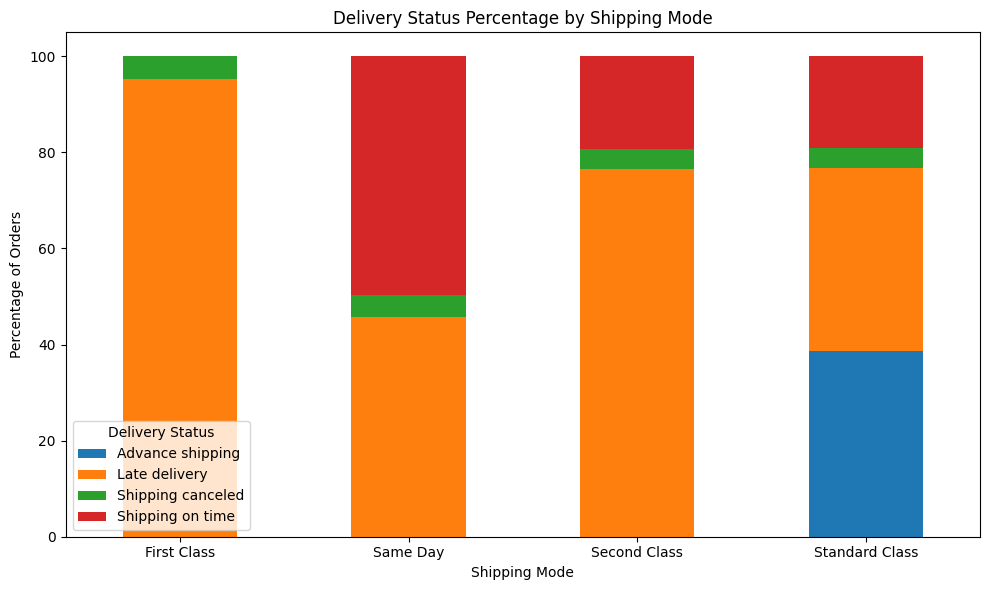

In [59]:
delivery_by_mode_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Delivery Status Percentage by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Percentage of Orders')
plt.xticks(rotation=0)
plt.legend(title='Delivery Status')
plt.tight_layout()
plt.show()

In [60]:
avg_shipping_by_mode = df_clean.groupby('Shipping Mode')[
    ['Days for shipping (real)', 'Days for shipment (scheduled)']
].mean()

print("Average shipping days by shipping mode:")
print(avg_shipping_by_mode.round(2))

Average shipping days by shipping mode:
                Days for shipping (real)  Days for shipment (scheduled)
Shipping Mode                                                          
First Class                         2.00                            1.0
Same Day                            0.48                            0.0
Second Class                        3.99                            2.0
Standard Class                      4.00                            4.0


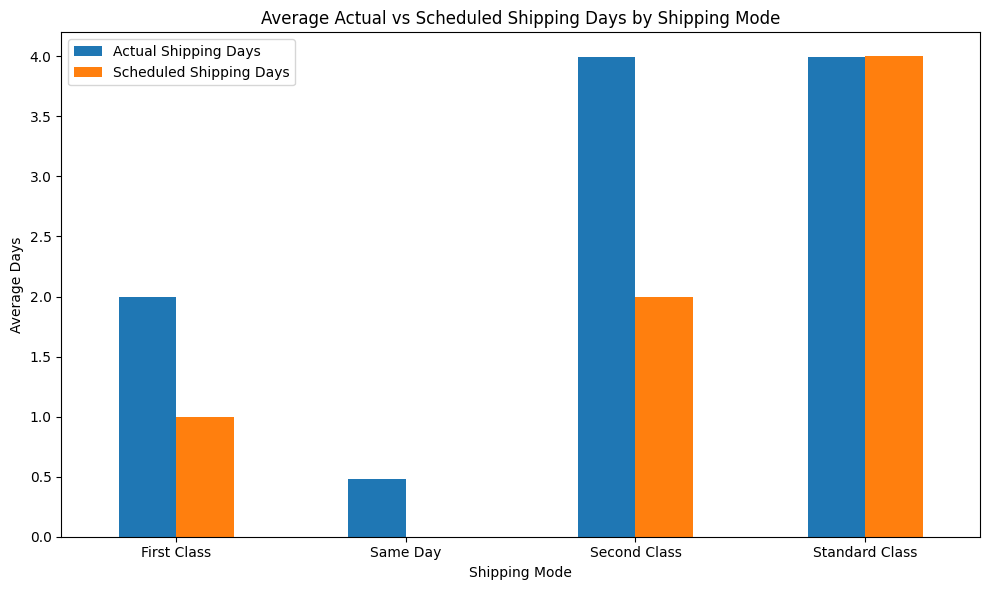

In [61]:
avg_shipping_by_mode.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Actual vs Scheduled Shipping Days by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Days')
plt.xticks(rotation=0)
plt.legend(
    ['Actual Shipping Days', 'Scheduled Shipping Days']
)
plt.tight_layout()
plt.show()

In [62]:
print("========== FINAL DATASET VERIFICATION ==========")

print("Final dataset shape:", df_clean_scaled.shape)
print("Total missing values:", df_clean_scaled.isnull().sum().sum())
print("Total duplicate rows:", df_clean_scaled.duplicated().sum())

print("\nDate column data types:")
print(df_clean_scaled[
    ['order date (DateOrders)', 'shipping date (DateOrders)']
].dtypes)

print("\nNormalized columns range:")
print(df_clean_scaled[scaling_columns].agg(['min', 'max']).round(2))

print("\nFinal verification completed successfully.")

========== FINAL DATASET VERIFICATION ==========
Final dataset shape: (180519, 51)
Total missing values: 0
Total duplicate rows: 0

Date column data types:
order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object

Normalized columns range:
     Sales  Order Item Discount  Order Item Product Price  \
min    0.0                  0.0                       0.0   
max    1.0                  1.0                       1.0   

     Order Profit Per Order  
min                     0.0  
max                     1.0  

Final verification completed successfully.


In [63]:
output_path = '/content/cleaned_logistics_dataset.csv'

df_clean_scaled.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print("File:", output_path)
print("Rows:", df_clean_scaled.shape[0])
print("Columns:", df_clean_scaled.shape[1])

Cleaned dataset saved successfully!
File: /content/cleaned_logistics_dataset.csv
Rows: 180519
Columns: 51
